In [1]:
from ERA_Distribution_Classes_Python.Classes.ERADist import ERADist
from ERA_Distribution_Classes_Python.Classes.ERANataf import ERANataf
from ERA_Distribution_Classes_Python.Classes.FORM_HLRF import FORM_HLRF
from ERA_Distribution_Classes_Python.Classes.FORM_fmincon import FORM_fmincon
import numpy as np
import matplotlib.pyplot as plt
from structure import Structure
from solver_2nd import Solver2ndOrder

## Material Properties

In [2]:
# modified IPE 120 -> eta Option 1 = 100%
E = 210e6 # kN/m2 
A = 1.321e-3 # m2
I = 0.3093e-5 # m4
h = 0.12  # m
z = h/2  # m
sigma_yield = 35.5 # m_k in kN/cm2 
alpha = 1.14
M_yield = I/z * sigma_yield * 100e2 * alpha # kNm

In [3]:
def t_R(M_k, I=I, z=z, alpha=alpha):
    """
    Takes in the Steel Bending Streng M_k (random variable) in kN/cm2
    I in m^4
    z in m
    alpha is the plastic ratio 

    Returns the characteristic Bending Moment Resistance M_c_Rk for the given system in kNm
    """
    return I/z * M_k * 100e2 * alpha

## System Definition

In [4]:
# Nodes

# Node 1 
x_1 = 0.0
z_1 = 0.0
# Node 2
x_2 = 0.1
z_2 = -3.0
# Node 3
x_3 = 3.6
z_3 = -3.0

# Load Distribution Length (Lasteinzugsbreite)
e = 5 # m

# Wind Last Beiwert (Bereich D)
c_pe = 0.8 

In [5]:
# Dimensions

# Outer dimensions for beam 1
delta_x_1 = x_2 - x_1
delta_z_1 = z_2 - z_1

# Outer dimensions for beam 2
delta_x_2 = x_3 - x_2
delta_z_2 = z_3 - z_2

In [6]:
def t_S(l_1, l_2, e=e, c_pe=c_pe): # Structural Model Function
    """
    l_1 = vertical load in kN/m2
    l_2 = horizontal load in kN/m2
    e = Load Distribution Length (Lasteinzugsbreite)
    """
    s = Structure()
    # Stab 1 
    n1 = s.add_node(x=delta_x_1 * 0/15,z=delta_z_1 * 0/15, kind="frame", support={"u": True, "w": True, "phi": False})
    n2 = s.add_node(x=delta_x_1 * 1/15,z=delta_z_1 * 1/15, kind="frame", support={"u": False, "w": False, "phi": False})
    n3 = s.add_node(x=delta_x_1 * 2/15,z=delta_z_1 * 2/15, kind="frame", support={"u": False, "w": False, "phi": False})
    n4 = s.add_node(x=delta_x_1 * 3/15,z=delta_z_1 * 3/15, kind="frame", support={"u": False, "w": False, "phi": False})
    n5 = s.add_node(x=delta_x_1 * 4/15,z=delta_z_1 * 4/15, kind="frame", support={"u": False, "w": False, "phi": False})
    n6 = s.add_node(x=delta_x_1 * 5/15,z=delta_z_1 * 5/15, kind="frame", support={"u": False, "w": False, "phi": False})
    n7 = s.add_node(x=delta_x_1 * 6/15,z=delta_z_1 * 6/15, kind="frame", support={"u": False, "w": False, "phi": False})
    n8 = s.add_node(x=delta_x_1 * 7/15,z=delta_z_1 * 7/15, kind="frame", support={"u": False, "w": False, "phi": False})
    n9 = s.add_node(x=delta_x_1 * 8/15,z=delta_z_1 * 8/15, kind="frame", support={"u": False, "w": False, "phi": False})
    n10 = s.add_node(x=delta_x_1 * 9/15,z=delta_z_1 * 9/15, kind="frame", support={"u": False, "w": False, "phi": False})
    n11 = s.add_node(x=delta_x_1 * 10/15,z=delta_z_1 * 10/15, kind="frame", support={"u": False, "w": False, "phi": False})
    n12 = s.add_node(x=delta_x_1 * 11/15,z=delta_z_1 * 11/15, kind="frame", support={"u": False, "w": False, "phi": False})
    n13 = s.add_node(x=delta_x_1 * 12/15,z=delta_z_1 * 12/15, kind="frame", support={"u": False, "w": False, "phi": False})
    n14 = s.add_node(x=delta_x_1 * 13/15,z=delta_z_1 * 13/15, kind="frame", support={"u": False, "w": False, "phi": False})
    n15 = s.add_node(x=delta_x_1 * 14/15,z=delta_z_1 * 14/15, kind="frame", support={"u": False, "w": False, "phi": False})
    n16 = s.add_node(x=delta_x_1 * 15/15,z=delta_z_1 * 15/15, kind="frame", support={"u": False, "w": False, "phi": False})

    e1 = s.add_element(node_i=n1,node_j=n2, E=E, A=A, I=I)
    e2 = s.add_element(node_i=n2,node_j=n3, E=E, A=A, I=I)
    e3 = s.add_element(node_i=n3,node_j=n4, E=E, A=A, I=I)
    e4 = s.add_element(node_i=n4,node_j=n5, E=E, A=A, I=I)
    e5 = s.add_element(node_i=n5,node_j=n6, E=E, A=A, I=I)
    e6 = s.add_element(node_i=n6,node_j=n7, E=E, A=A, I=I)
    e7 = s.add_element(node_i=n7,node_j=n8, E=E, A=A, I=I)
    e8 = s.add_element(node_i=n8,node_j=n9, E=E, A=A, I=I)
    e9 = s.add_element(node_i=n9,node_j=n10, E=E, A=A, I=I)
    e10 = s.add_element(node_i=n10,node_j=n11, E=E, A=A, I=I)
    e11 = s.add_element(node_i=n11,node_j=n12, E=E, A=A, I=I)
    e12 = s.add_element(node_i=n12,node_j=n13, E=E, A=A, I=I)
    e13 = s.add_element(node_i=n13,node_j=n14, E=E, A=A, I=I)
    e14 = s.add_element(node_i=n14,node_j=n15, E=E, A=A, I=I)
    e15 = s.add_element(node_i=n15,node_j=n16, E=E, A=A, I=I)

    # Stab 2
    n17 = s.add_node(x=x_2 + delta_x_2 * 1/17,z=z_2 + delta_z_2 * 1/17,kind="frame", support={"u": False, "w": False, "phi": False})
    n18 = s.add_node(x=x_2 + delta_x_2 * 2/17,z=z_2 + delta_z_2 * 2/17,kind="frame", support={"u": False, "w": False, "phi": False})
    n19 = s.add_node(x=x_2 + delta_x_2 * 3/17,z=z_2 + delta_z_2 * 3/17,kind="frame", support={"u": False, "w": False, "phi": False})
    n20 = s.add_node(x=x_2 + delta_x_2 * 4/17,z=z_2 + delta_z_2 * 4/17,kind="frame", support={"u": False, "w": False, "phi": False})
    n21 = s.add_node(x=x_2 + delta_x_2 * 5/17,z=z_2 + delta_z_2 * 5/17,kind="frame", support={"u": False, "w": False, "phi": False})
    n22 = s.add_node(x=x_2 + delta_x_2 * 6/17,z=z_2 + delta_z_2 * 6/17,kind="frame", support={"u": False, "w": False, "phi": False})
    n23 = s.add_node(x=x_2 + delta_x_2 * 7/17,z=z_2 + delta_z_2 * 7/17,kind="frame", support={"u": False, "w": False, "phi": False})
    n24 = s.add_node(x=x_2 + delta_x_2 * 8/17,z=z_2 + delta_z_2 * 8/17,kind="frame", support={"u": False, "w": False, "phi": False})
    n25 = s.add_node(x=x_2 + delta_x_2 * 9/17,z=z_2 + delta_z_2 * 9/17,kind="frame", support={"u": False, "w": False, "phi": False})
    n26 = s.add_node(x=x_2 + delta_x_2 * 10/17,z=z_2 + delta_z_2 * 10/17,kind="frame", support={"u": False, "w": False, "phi": False})
    n27 = s.add_node(x=x_2 + delta_x_2 * 11/17,z=z_2 + delta_z_2 * 11/17,kind="frame", support={"u": False, "w": False, "phi": False})
    n28 = s.add_node(x=x_2 + delta_x_2 * 12/17,z=z_2 + delta_z_2 * 12/17,kind="frame", support={"u": False, "w": False, "phi": False})
    n29 = s.add_node(x=x_2 + delta_x_2 * 13/17,z=z_2 + delta_z_2 * 13/17,kind="frame", support={"u": False, "w": False, "phi": False})
    n30 = s.add_node(x=x_2 + delta_x_2 * 14/17,z=z_2 + delta_z_2 * 14/17,kind="frame", support={"u": False, "w": False, "phi": False})
    n31 = s.add_node(x=x_2 + delta_x_2 * 15/17,z=z_2 + delta_z_2 * 15/17,kind="frame", support={"u": False, "w": False, "phi": False})
    n32 = s.add_node(x=x_2 + delta_x_2 * 16/17,z=z_2 + delta_z_2 * 16/17,kind="frame", support={"u": False, "w": False, "phi": False})
    n33 = s.add_node(x=x_2 + delta_x_2 * 17/17,z=z_2 + delta_z_2 * 17/17,kind="frame", support={"u": False, "w": True, "phi": False})

    e16 = s.add_element(node_i=n16,node_j=n17, E=E, A=A, I=I)
    e17 = s.add_element(node_i=n17,node_j=n18, E=E, A=A, I=I)
    e18 = s.add_element(node_i=n18,node_j=n19, E=E, A=A, I=I)
    e19 = s.add_element(node_i=n19,node_j=n20, E=E, A=A, I=I)
    e20 = s.add_element(node_i=n20,node_j=n21, E=E, A=A, I=I)
    e21 = s.add_element(node_i=n21,node_j=n22, E=E, A=A, I=I)
    e22 = s.add_element(node_i=n22,node_j=n23, E=E, A=A, I=I)
    e23 = s.add_element(node_i=n23,node_j=n24, E=E, A=A, I=I)
    e24 = s.add_element(node_i=n24,node_j=n25, E=E, A=A, I=I)
    e25 = s.add_element(node_i=n25,node_j=n26, E=E, A=A, I=I)
    e26 = s.add_element(node_i=n26,node_j=n27, E=E, A=A, I=I)
    e27 = s.add_element(node_i=n27,node_j=n28, E=E, A=A, I=I)
    e28 = s.add_element(node_i=n28,node_j=n29, E=E, A=A, I=I)
    e29 = s.add_element(node_i=n29,node_j=n30, E=E, A=A, I=I)
    e30 = s.add_element(node_i=n30,node_j=n31, E=E, A=A, I=I)
    e31 = s.add_element(node_i=n31,node_j=n32, E=E, A=A, I=I)
    e32 = s.add_element(node_i=n32,node_j=n33, E=E, A=A, I=I)

    # Surface Load (kN/m2) -> Line Load (kN/m)
    l_1 *= e
    l_2 *= (e * c_pe)

    # Vertical Load on Beam 2
    s.add_dist_load(e16, qz=l_1, local=True)
    s.add_dist_load(e17, qz=l_1, local=True)
    s.add_dist_load(e18, qz=l_1, local=True)
    s.add_dist_load(e19, qz=l_1, local=True)
    s.add_dist_load(e20, qz=l_1, local=True)
    s.add_dist_load(e21, qz=l_1, local=True)
    s.add_dist_load(e22, qz=l_1, local=True)
    s.add_dist_load(e23, qz=l_1, local=True)
    s.add_dist_load(e24, qz=l_1, local=True)
    s.add_dist_load(e25, qz=l_1, local=True)
    s.add_dist_load(e26, qz=l_1, local=True)
    s.add_dist_load(e27, qz=l_1, local=True)
    s.add_dist_load(e28, qz=l_1, local=True)
    s.add_dist_load(e29, qz=l_1, local=True)
    s.add_dist_load(e30, qz=l_1, local=True)
    s.add_dist_load(e31, qz=l_1, local=True)
    s.add_dist_load(e32, qz=l_1, local=True) 


    # Wind Load on Beam 1 
    s.add_dist_load(e1, qz=l_2, local=True)
    s.add_dist_load(e2, qz=l_2, local=True)
    s.add_dist_load(e3, qz=l_2, local=True)
    s.add_dist_load(e4, qz=l_2, local=True)
    s.add_dist_load(e5, qz=l_2, local=True)
    s.add_dist_load(e6, qz=l_2, local=True)
    s.add_dist_load(e7, qz=l_2, local=True)
    s.add_dist_load(e8, qz=l_2, local=True)
    s.add_dist_load(e9, qz=l_2, local=True)
    s.add_dist_load(e10, qz=l_2, local=True)
    s.add_dist_load(e11, qz=l_2, local=True)
    s.add_dist_load(e12, qz=l_2, local=True)
    s.add_dist_load(e13, qz=l_2, local=True)
    s.add_dist_load(e14, qz=l_2, local=True)
    s.add_dist_load(e15, qz=l_2, local=True)


    #solver1 = Solver1stOrder()
    solver2 = Solver2ndOrder(tol=1e-6, max_iter=60)

    print(f"l_1 = {l_1}")
    print(f"l_2 = {l_2}")
    #res1 = solver1.solve(s)
    res2 = solver2.solve(s)

    #res1.print_summary()
    #res2.print_summary()

    M_max = res2.internal_forces(s.elements[14])["M_j"]

    return M_max

In [7]:
# Vectorized Version of the Structural response function (Better for array handling later)
t_S_vectorized = np.vectorize(t_S, otypes=[float])

## Characteristic Values (for calibrating the probabilistic loads)

In [8]:
s_k = 1.1 # snow load on ground kN/m2
q_b = 0.65 # wind pressure kN/m2
w_k = q_b * c_pe # wind load kN/m2 with c_pe,10 = 0.8 (Area D)
m_k = 35.5 # kN/cm2 (steel yield resistance)

In [9]:
# # Quick Check: should give 20.86 kNm
# print(t_S(l_1=s_k * 1.5, l_2=q_b * 1.5))

## Distributions

In [10]:
# Snow time-invariant part
mu_Theta_1 = 0.81
cov_Theta_1 = 0.26
sig_Theta_1 = mu_Theta_1 * cov_Theta_1
Theta_L1 = ERADist('lognormal','MOM',[mu_Theta_1, sig_Theta_1])

# Snow load on ground
mu_L1 = 1.0
cov_L1 = 0.2
sig_L1 = mu_L1 * cov_L1
L1 = ERADist('gumbel','MOM',[mu_L1,sig_L1])

In [11]:
percentile_L1 = L1.icdf(0.98)
print(f"Snow 98% Percentile: {percentile_L1}")

Snow 98% Percentile: 1.5184551765313796


In [12]:
# Wind time-invariant part
mu_Theta_2 = 0.97
cov_Theta_2 = 0.26
sig_Theta_2 = mu_Theta_2 * cov_Theta_2
Theta_L2 = ERADist('lognormal','MOM',[mu_Theta_2, sig_Theta_2])

# Wind velocity pressure
mu_L2 = 1.0 
cov_L2 = 0.14
sig_L2 = mu_L2 * cov_L2
L2 = ERADist('gumbel','MOM',[mu_L2, sig_L2])

In [13]:
percentile_L2 = L2.icdf(0.98)
print(f"Wind 98% Percentile: {percentile_L2}")

Wind 98% Percentile: 1.3629186235719657


In [14]:
# Structural Response Model Uncertainty (from JCSS Probabilistic Model Code, Part 3, Table 3.9.1)
mu_Theta_S = 1.0
cov_Theta_S = 0.1
sig_Theta_S = mu_Theta_S * cov_Theta_S
Theta_S = ERADist('lognormal','MOM',[mu_Theta_S, sig_Theta_S])  # Distribution for Moments in frames

In [15]:
# Steel bending model uncertainty
mu_Theta_M = 1.15
cov_Theta_M = 0.05
sig_Theta_M = mu_Theta_M * cov_Theta_M
Theta_M = ERADist('lognormal','MOM',[mu_Theta_M, sig_Theta_M])

# Steel yielding strength
mu_M = 1.0
cov_M = 0.05
sig_M = mu_M * cov_M
M = ERADist('lognormal','MOM',[mu_M, sig_M])

In [16]:
percentile_M = M.icdf(0.05)
print(f"Steel 5% Percentile: {percentile_M}")

Steel 5% Percentile: 0.9199464756612658


## Shifting / Scaling Distributions

In [17]:
# Snow Load on Ground, shifted to characteristic value
snow_shift = s_k / percentile_L1 # ratio of target to current percentile, by which mean and std get multiplied

mu_L1_shifted = mu_L1 * snow_shift
sig_L1_shifted = sig_L1 * snow_shift
L1_shifted = ERADist('gumbel','MOM',[mu_L1_shifted, sig_L1_shifted])

print(f"""Snow Load on Ground gets shifted by {snow_shift}""")
print(f"""Old mean: {mu_L1}; New mean: {mu_L1_shifted}""")
print(f"""Old std: {sig_L1}; New std: {sig_L1_shifted}""")
print(f"""Old 98th percentile: {L1.icdf(.98)}; New 98th percentile: {L1_shifted.icdf(.98)}""")
print(f"""Old COV: {L1.std()/L1.mean()}; New COV: {L1_shifted.std()/L1_shifted.mean()}""")

Snow Load on Ground gets shifted by 0.7244204616646898
Old mean: 1.0; New mean: 0.7244204616646898
Old std: 0.2; New std: 0.14488409233293795
Old 98th percentile: 1.5184551765313796; New 98th percentile: 1.0999999999999999
Old COV: 0.19999999999999998; New COV: 0.19999999999999996


In [18]:
# Wind velocity pressure, shifted to characteristic value
wind_shift = q_b / percentile_L2

mu_L2_shifted = mu_L2 * wind_shift
sig_L2_shifted = sig_L2 * wind_shift
L2_shifted = ERADist('gumbel','MOM',[mu_L2_shifted, sig_L2_shifted])

print(f"""Wind velocity pressure gets shifted by {wind_shift}""")
print(f"""Old mean: {mu_L2}; New mean: {mu_L2_shifted}""")
print(f"""Old std: {sig_L2}; New std: {sig_L2_shifted}""")
print(f"""Old 98th percentile: {L2.icdf(.98)}; New 98th percentile: {L2_shifted.icdf(.98)}""")
print(f"""Old COV: {L2.std()/L2.mean()}; New COV: {L2_shifted.std()/L2_shifted.mean()}""")

Wind velocity pressure gets shifted by 0.4769176888173018
Old mean: 1.0; New mean: 0.4769176888173018
Old std: 0.14; New std: 0.06676847643442226
Old 98th percentile: 1.3629186235719657; New 98th percentile: 0.65
Old COV: 0.14; New COV: 0.13999999999999999


In [19]:
# Steel bending resistance, shifted to characteristic value
steel_shift = m_k / percentile_M

mu_M_shifted = mu_M * steel_shift
sig_M_shifted = sig_M * steel_shift
M_shifted = ERADist('lognormal','MOM',[mu_M_shifted, sig_M_shifted])

print(f"""Steel bending resistance gets shifted by {steel_shift}""")
print(f"""Old mean: {mu_M}; New mean: {mu_M_shifted}""")
print(f"""Old std: {sig_M}; New std: {sig_M_shifted}""")
print(f"""Old 5th percentile: {M.icdf(0.05)}; New 5th percentile: {M_shifted.icdf(0.05)}""")
print(f"""Old COV: {M.std()/M.mean()}; New COV: {M_shifted.std()/M_shifted.mean()}""")

Steel bending resistance gets shifted by 38.58920158858403
Old mean: 1.0; New mean: 38.58920158858403
Old std: 0.05; New std: 1.9294600794292016
Old 5th percentile: 0.9199464756612658; New 5th percentile: 35.5
Old COV: 0.04999999999999947; New COV: 0.04999999999999946


### Distribution Plots

In [20]:
x_plotting = np.linspace(0, 2.0, 200) # for PDF plotting only
x_resistance_plotting = np.linspace(30, 50, 200) # for PDF plotting only

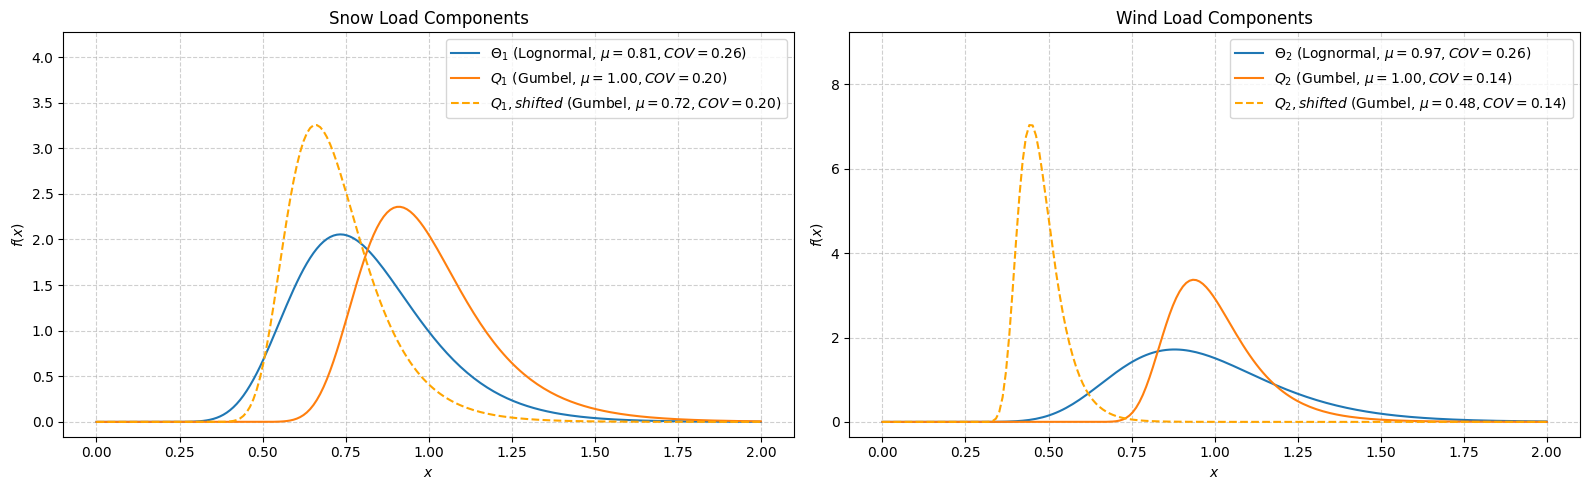

In [21]:
# FIGURE 1: LOADS Side by side
# ================================================================================
fig1, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Left Plot: SNOW ---
axes[0].plot(x_plotting, Theta_L1.pdf(x_plotting), label=fr'$\Theta_1$ (Lognormal, $\mu={Theta_L1.mean():.2f}, COV={Theta_L1.std()/Theta_L1.mean():.2f}$)')
axes[0].plot(x_plotting, L1.pdf(x_plotting), label=fr'$Q_1$ (Gumbel, $\mu={L1.mean():.2f}, COV={L1.std()/L1.mean():.2f}$)')
axes[0].plot(x_plotting, L1_shifted.pdf(x_plotting), label=fr'$Q_1,shifted$ (Gumbel, $\mu={L1_shifted.mean():.2f}, COV={L1_shifted.std()/L1_shifted.mean():.2f}$)', linestyle= "--", color = "orange")
axes[0].set_title('Snow Load Components')
axes[0].set_xlabel('$x$')
axes[0].set_ylabel('$f(x)$')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend(fontsize="medium")
axes[0].set_ylim(top=axes[0].get_ylim()[1] * 1.25)

# --- Right Plot: WIND ---
axes[1].plot(x_plotting, Theta_L2.pdf(x_plotting), label=fr'$\Theta_2$ (Lognormal, $\mu={Theta_L2.mean():.2f}, COV={Theta_L2.std()/Theta_L2.mean():.2f}$)')
axes[1].plot(x_plotting, L2.pdf(x_plotting), label=fr'$Q_2$ (Gumbel, $\mu={L2.mean():.2f}, COV={L2.std()/L2.mean():.2f}$)')
axes[1].plot(x_plotting, L2_shifted.pdf(x_plotting), label=fr'$Q_2,shifted$ (Gumbel, $\mu={L2_shifted.mean():.2f}, COV={L2_shifted.std()/L2_shifted.mean():.2f}$)', linestyle= "--", color = "orange")
axes[1].set_title('Wind Load Components')
axes[1].set_xlabel('$x$')
axes[1].set_ylabel('$f(x)$')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(fontsize="medium")
axes[1].set_ylim(top=axes[1].get_ylim()[1] * 1.25)

fig1.tight_layout()
plt.show()


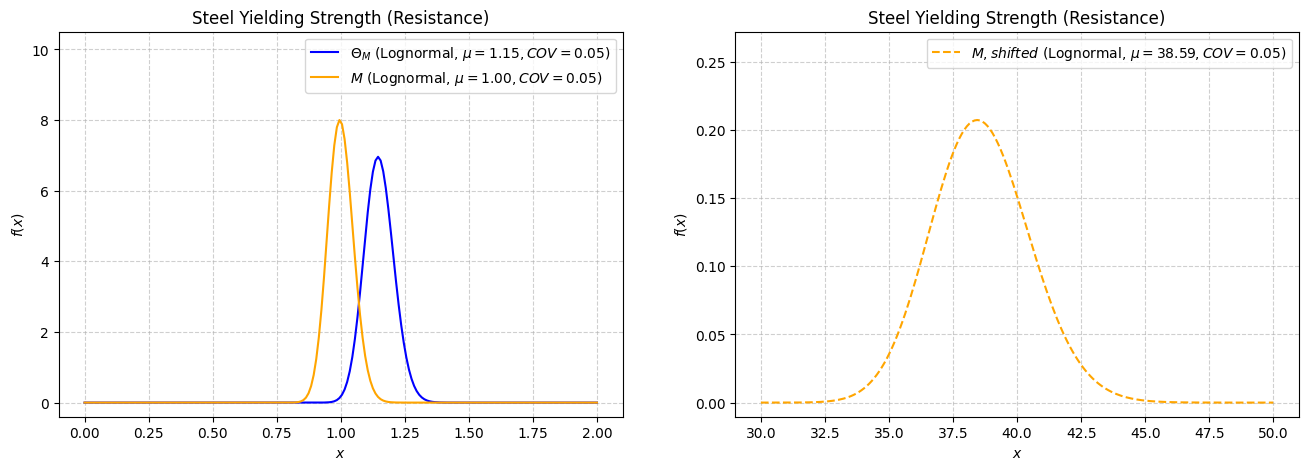

In [22]:
# FIGURE 2: Resistance
# ================================================================================
fig2, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Left Plot: Resistance Original ---
axes[0].plot(x_plotting, Theta_M.pdf(x_plotting), label=fr'$\Theta_M$ (Lognormal, $\mu={Theta_M.mean():.2f}, COV={Theta_M.std()/Theta_M.mean():.2f}$)', color='blue')
axes[0].plot(x_plotting, M.pdf(x_plotting), label=fr'$M$ (Lognormal, $\mu={M.mean():.2f}, COV={M.std()/M.mean():.2f}$)', color='orange')
axes[0].set_title('Steel Yielding Strength (Resistance)')
axes[0].set_xlabel('$x$')
axes[0].set_ylabel('$f(x)$')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend(fontsize="medium")
axes[0].set_ylim(top=axes[0].get_ylim()[1] * 1.25)

# --- Right Plot: Resistance Shifted (without Model uncertainty) --
axes[1].plot(x_resistance_plotting, M_shifted.pdf(x_resistance_plotting), label=fr'$M,shifted$ (Lognormal, $\mu={M_shifted.mean():.2f}, COV={M_shifted.std()/M_shifted.mean():.2f}$)', color='orange', linestyle= "--")
axes[1].set_title('Steel Yielding Strength (Resistance)')
axes[1].set_xlabel('$x$')
axes[1].set_ylabel('$f(x)$')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(fontsize="medium")
axes[1].set_ylim(top=axes[1].get_ylim()[1] * 1.25)

fig1.tight_layout()
plt.show()

## Partial Safety Factors

In [23]:
gamma_M = 1.0  # Resistance
gamma_F1 = 1.5   # Snow Load
gamma_F2 = 1.5   # Wind Load
#psi_0 = 1.0 # 0.6     # Windload

## Subset Simulation

In [24]:
# Set random seed for reproducibility
np.random.seed(42)

In [25]:
# n_samples = 100

# # TODO: Update on new ordering and R1 -> M1 ; Theta_R -> Theta_M
# X1 = Theta_L1.random(n_samples)     # Snow time invariant part
# X2 = L1_shifted.random(n_samples)   # Snow load on ground
# X3 = Theta_L2.random(n_samples)     # Wind time invariant part
# X4 = L2_shifted.random(n_samples)   # Wind velocity pressure
# X5 = Theta_S.random(n_samples)      # Structural Response Model Uncertainty
# X6 = Theta_M.random(n_samples)      # Steel bending model uncertainty
# X7 = M_shifted.random(n_samples)   # Steel yielding resistance

In [26]:
# # Run MCS

# # TODO: Update on new ordering and R1 -> M1 ; Theta_R -> Theta_M
# option_1_MCS_array = g_opt_1(Theta_R=X6, R=X7, Theta_L1=X1, L1=X2, Theta_L2=X3, L2=X4, Theta_S=X5)

In [27]:
# # Number of failures where g <= 0
# num_failures = np.sum(option_1_MCS_array <= 0)

# # Probability of Failure
# P_f = num_failures / n_samples

# # Reliability Index
# normal_dist = ERADist('standardnormal','PAR',[])
# beta = - normal_dist.icdf(P_f)

# print(f"Probability of failure: {P_f}")
# print(f"Reliability Index: {beta}")

## FORM Analysis

In [28]:
# Array of marginal distributions
marginal_dist = [Theta_M, M_shifted, Theta_L1, L1_shifted, Theta_L2, L2_shifted, Theta_S]
# Correlation matrix (no correlation yet)
dimensions = len(marginal_dist)
R_xx = np.eye(dimensions)

# Cosntruction of the Nataf Distribution
nataf = ERANataf(M=marginal_dist, Correlation=R_xx)


### Limit State Functions

In [29]:
def g_opt_1(x):
    """
    x[0]: Theta_M = Resistance Model Uncertainty
    x[1]: M = Steel yield strength
    x[2]: Theta_L1 = Snow Load Model Uncertainty
    x[3]: L1 = Snow Load on Ground
    x[4]: Theta_L2 = Wind Load Model Uncertainty
    x[5]: L2 = Wind velocity pressure
    x[6]: Theta_S = Structural Response Model Uncertainty
    """
    
    resistance = x[0] * t_R(M_k=x[1]) / gamma_M
    
    # JO: Custom constraints to stay in reasonable load regimes
    upper_L1 = 1.25   # physical upper limit for Snow Load on Ground
    upper_L2 = 0.75   # physical upper limit for Wind velocity pressure
    
    # Clip physically unreasonable values before evaluation
    x[3] = np.clip(x[3], a_min=None, a_max=upper_L1)
    x[5] = np.clip(x[5], a_min=None, a_max=upper_L2)
    
    # only calculate response once, for speed
    structural_response = t_S_vectorized(l_1=(x[2] * gamma_F1 * x[3]), l_2=(x[4] * gamma_F2 * x[5]))
    action = x[6] * structural_response
    print(f"action = {action}")
    print(f"resistance = {resistance}")
    return resistance - action

In [30]:
def g_opt_2(x):
    """
    x[0]: Theta_M = Resistance Model Uncertainty
    x[1]: M = Steel yield strength
    x[2]: Theta_L1 = Snow Load Model Uncertainty
    x[3]: L1 = Snow Load on Ground
    x[4]: Theta_L2 = Wind Load Model Uncertainty
    x[5]: L2 = Wind velocity pressure
    x[6]: Theta_S = Structural Response Model Uncertainty
    """
    resistance = x[0] * t_R(M_k=x[1]) / gamma_M
    
    argument1 = gamma_F1 * x[6] * t_S_vectorized(l_1=(x[2] * x[3]), l_2=(gamma_F2/gamma_F1 * x[4] * x[5]))
    argument2 = gamma_F2 * x[6] * t_S_vectorized(l_1=(gamma_F1/gamma_F2 * x[2] * x[3]), l_2=(x[4] * x[5]))
    action = np.max(argument1, argument2)
    return resistance - action

In [36]:
def g_opt_2_1(x):
    """
    x[0]: Theta_M = Resistance Model Uncertainty
    x[1]: M = Steel yield strength
    x[2]: Theta_L1 = Snow Load Model Uncertainty
    x[3]: L1 = Snow Load on Ground
    x[4]: Theta_L2 = Wind Load Model Uncertainty
    x[5]: L2 = Wind velocity pressure
    x[6]: Theta_S = Structural Response Model Uncertainty
    """
    resistance = x[0] * t_R(M_k=x[1]) / gamma_M
    
    # JO: Custom constraints to stay in reasonable load regimes
    upper_L1 = 1.25   # physical upper limit for Snow Load on Ground
    upper_L2 = 0.75   # physical upper limit for Wind velocity pressure
    
    # Clip physically unreasonable values before evaluation
    x[3] = np.clip(x[3], a_min=None, a_max=upper_L1)
    x[5] = np.clip(x[5], a_min=None, a_max=upper_L2)
    
    argument1 = gamma_F1 * x[6] * t_S_vectorized(l_1=(x[2] * x[3]), l_2=(gamma_F2/gamma_F1 * x[4] * x[5]))
    action = argument1
    return resistance - action

In [32]:
def g_opt_2_2(x):
    """
    x[0]: Theta_M = Resistance Model Uncertainty
    x[1]: M = Steel yield strength
    x[2]: Theta_L1 = Snow Load Model Uncertainty
    x[3]: L1 = Snow Load on Ground
    x[4]: Theta_L2 = Wind Load Model Uncertainty
    x[5]: L2 = Wind velocity pressure
    x[6]: Theta_S = Structural Response Model Uncertainty
    """
    resistance = x[0] * t_R(M_k=x[1]) / gamma_M
    
    # JO: Custom constraints to stay in reasonable load regimes
    upper_L1 = 1.25   # physical upper limit for Snow Load on Ground
    upper_L2 = 0.75   # physical upper limit for Wind velocity pressure
    
    # Clip physically unreasonable values before evaluation
    x[3] = np.clip(x[3], a_min=None, a_max=upper_L1)
    x[5] = np.clip(x[5], a_min=None, a_max=upper_L2)
    
    argument2 = gamma_F2 * x[6] * t_S_vectorized(l_1=(gamma_F1/gamma_F2 * x[2] * x[3]), l_2=(x[4] * x[5]))
    action = argument2
    return resistance - action

### Design Option 1

In [42]:
# Perform FORM with HLRF
# [u_star, x_star, beta, Pf, S_F1, S_F1_T] = FORM_HLRF(g=g_opt_1, dg=[], distr=nataf, sensitivity_analysis=0, u0=1)

# Perform FORM with fmincom
[u_star, x_star, beta, alpha, Pf] = FORM_fmincon(g=g_opt_1, dg=[], distr=nataf)

l_1 = 4.305857008539695
l_2 = 2.7278034558791657
  Iteration  1: ||Δu|| = 3.51e-02
  Iteration  2: ||Δu|| = 1.81e-03
  Iteration  3: ||Δu|| = 9.28e-05
  Iteration  4: ||Δu|| = 4.77e-06
  Iteration  5: ||Δu|| = 2.45e-07
  Konvergiert nach 5 Iterationen.
action = 13.38401479642002
resistance = 26.27562210703656
l_1 = 4.305857008539695
l_2 = 2.7278034558791657
  Iteration  1: ||Δu|| = 3.51e-02
  Iteration  2: ||Δu|| = 1.81e-03
  Iteration  3: ||Δu|| = 9.28e-05
  Iteration  4: ||Δu|| = 4.77e-06
  Iteration  5: ||Δu|| = 2.45e-07
  Konvergiert nach 5 Iterationen.
action = 13.38401479642002
resistance = 26.27562210703656
l_1 = 4.305857008539695
l_2 = 2.7278034558791657
  Iteration  1: ||Δu|| = 3.51e-02
  Iteration  2: ||Δu|| = 1.81e-03
  Iteration  3: ||Δu|| = 9.28e-05
  Iteration  4: ||Δu|| = 4.77e-06
  Iteration  5: ||Δu|| = 2.45e-07
  Konvergiert nach 5 Iterationen.
action = 13.38401479642002
resistance = 26.275622126601203
l_1 = 4.305857008539695
l_2 = 2.7278034558791657
  Iteration  1: |

In [34]:
print(f"u_star = {u_star}")
print(f"x_star = {x_star}")
print(f"beta = {beta}")
print(f"P(F) = {Pf}")
print(f"g(X*) = {g_opt_1(x_star)}")

u_star = [-0.40378368 -0.40378393  0.25005144  0.18719994  1.84238948  1.21528311
  0.80516857]
x_star = [ 1.12562329 37.77122051  0.83570929  0.72578998  1.50387275  0.55771424
  1.07825229]
beta = 2.4378803757775653
P(F) = 0.0073868310148014794
l_1 = 4.549120753047037
l_2 = 5.032387478767937
  Iteration  1: ||Δu|| = 2.09e-02
  Iteration  2: ||Δu|| = 1.70e-03
  Iteration  3: ||Δu|| = 1.37e-04
  Iteration  4: ||Δu|| = 1.11e-05
  Iteration  5: ||Δu|| = 9.02e-07
  Konvergiert nach 5 Iterationen.
action = 24.985474346420112
resistance = 24.985475019972167
g(X*) = 6.735520550193996e-07


### Design Option 2.1

In [44]:
# Perform FORM with HLRF
# [u_star, x_star, beta, Pf, S_F1, S_F1_T] = FORM_HLRF(g=g_opt_2_1, dg=[], distr=nataf, sensitivity_analysis=0, u0=1)

# Perform FORM with fmincom
[u_star, x_star, beta, alpha, Pf] = FORM_fmincon(g=g_opt_2_1, dg=[], distr=nataf)

l_1 = 2.870571339026463
l_2 = 1.8185356372527772
  Iteration  1: ||Δu|| = 1.54e-02
  Iteration  2: ||Δu|| = 5.15e-04
  Iteration  3: ||Δu|| = 1.72e-05
  Iteration  4: ||Δu|| = 5.76e-07
  Konvergiert nach 4 Iterationen.
l_1 = 2.870571339026463
l_2 = 1.8185356372527772
  Iteration  1: ||Δu|| = 1.54e-02
  Iteration  2: ||Δu|| = 5.15e-04
  Iteration  3: ||Δu|| = 1.72e-05
  Iteration  4: ||Δu|| = 5.76e-07
  Konvergiert nach 4 Iterationen.
l_1 = 2.870571339026463
l_2 = 1.8185356372527772
  Iteration  1: ||Δu|| = 1.54e-02
  Iteration  2: ||Δu|| = 5.15e-04
  Iteration  3: ||Δu|| = 1.72e-05
  Iteration  4: ||Δu|| = 5.76e-07
  Konvergiert nach 4 Iterationen.
l_1 = 2.870571339026463
l_2 = 1.8185356372527772
  Iteration  1: ||Δu|| = 1.54e-02
  Iteration  2: ||Δu|| = 5.15e-04
  Iteration  3: ||Δu|| = 1.72e-05
  Iteration  4: ||Δu|| = 5.76e-07
  Konvergiert nach 4 Iterationen.
l_1 = 2.870571349966555
l_2 = 1.8185356372527772
  Iteration  1: ||Δu|| = 1.54e-02
  Iteration  2: ||Δu|| = 5.15e-04
  Itera

In [38]:
print(f"u_star = {u_star}")
print(f"x_star = {x_star}")
print(f"beta = {beta}")
print(f"P(F) = {Pf}")
print(f"g(X*) = {g_opt_2_1(x_star)}")

u_star = [-0.39719167 -0.39719163  0.18932774  0.13873482  1.86787293  1.23716884
  0.79290415]
x_star = [ 1.12599413 37.78366474  0.82283042  0.71911058  1.51370647  0.55977966
  1.07693397]
beta = 2.4533340100756904
P(F) = 0.007076942301743444
l_1 = 2.958530287778514
l_2 = 3.3893683598757316
  Iteration  1: ||Δu|| = 7.65e-03
  Iteration  2: ||Δu|| = 4.11e-04
  Iteration  3: ||Δu|| = 2.20e-05
  Iteration  4: ||Δu|| = 1.18e-06
  Iteration  5: ||Δu|| = 6.34e-08
  Konvergiert nach 5 Iterationen.
g(X*) = 6.375260994673226e-07


### Design Option 2.2 

In [39]:
# Perform FORM with HLRF
# [u_star, x_star, beta, Pf, S_F1, S_F1_T] = FORM_HLRF(g=g_opt_2_2, dg=[], distr=nataf, sensitivity_analysis=0, u0=1)

# Perform FORM with fmincom
[u_star, x_star, beta, alpha, Pf] = FORM_fmincon(g=g_opt_2_2, dg=[], distr=nataf)

l_1 = 2.870571339026463
l_2 = 1.8185356372527772
  Iteration  1: ||Δu|| = 1.54e-02
  Iteration  2: ||Δu|| = 5.15e-04
  Iteration  3: ||Δu|| = 1.72e-05
  Iteration  4: ||Δu|| = 5.76e-07
  Konvergiert nach 4 Iterationen.
l_1 = 2.870571339026463
l_2 = 1.8185356372527772
  Iteration  1: ||Δu|| = 1.54e-02
  Iteration  2: ||Δu|| = 5.15e-04
  Iteration  3: ||Δu|| = 1.72e-05
  Iteration  4: ||Δu|| = 5.76e-07
  Konvergiert nach 4 Iterationen.
l_1 = 2.870571339026463
l_2 = 1.8185356372527772
  Iteration  1: ||Δu|| = 1.54e-02
  Iteration  2: ||Δu|| = 5.15e-04
  Iteration  3: ||Δu|| = 1.72e-05
  Iteration  4: ||Δu|| = 5.76e-07
  Konvergiert nach 4 Iterationen.
l_1 = 2.870571339026463
l_2 = 1.8185356372527772
  Iteration  1: ||Δu|| = 1.54e-02
  Iteration  2: ||Δu|| = 5.15e-04
  Iteration  3: ||Δu|| = 1.72e-05
  Iteration  4: ||Δu|| = 5.76e-07
  Konvergiert nach 4 Iterationen.
l_1 = 2.870571349966555
l_2 = 1.8185356372527772
  Iteration  1: ||Δu|| = 1.54e-02
  Iteration  2: ||Δu|| = 5.15e-04
  Itera

In [40]:
print(f"u_star = {u_star}")
print(f"x_star = {x_star}")
print(f"beta = {beta}")
print(f"P(F) = {Pf}")
print(f"g(X*) = {g_opt_2_2(x_star)}")

u_star = [-0.39719167 -0.39719163  0.18932774  0.13873482  1.86787293  1.23716884
  0.79290415]
x_star = [ 1.12599413 37.78366474  0.82283042  0.71911058  1.51370647  0.55977966
  1.07693397]
beta = 2.4533340100756904
P(F) = 0.007076942301743444
l_1 = 2.958530287778514
l_2 = 3.3893683598757316
  Iteration  1: ||Δu|| = 7.65e-03
  Iteration  2: ||Δu|| = 4.11e-04
  Iteration  3: ||Δu|| = 2.20e-05
  Iteration  4: ||Δu|| = 1.18e-06
  Iteration  5: ||Δu|| = 6.34e-08
  Konvergiert nach 5 Iterationen.
g(X*) = 6.375260994673226e-07
